#Sığorta Sektorunda Müştəri Davranışı Analizi (Churn Prediction)

**Layihənin Məqsədi:** 
Bu layihənin məqsədi, anonimləşdirilmiş sığorta datası  üzərində maşın öyrənməsi modelləri quraraq, gələcəkdə xidmətdən imtina etmə (churn) riski olan müştəriləri əvvəlcədən müəyyən etməkdir.

**Əsas Çətinlik:** Datanın kəskin balanssız (imbalanced) olması (Sadiq müştərilər çox, gedənlər azdır).

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# Qrafiklərin notebook-da düzgün görünməsi üçün
%matplotlib inline

print("Kitabxanalar uğurla yükləndi!")

Kitabxanalar uğurla yükləndi!


### 1. Datanın Yüklənməsi və Təhlili (EDA)
Kaggle-dan əldə etdiyimiz `train.csv` (öyrənmə üçün) və `test.csv` (son proqnoz üçün) fayllarını yükləyirik. İlk öncə məlumatların strukturuna və hədəf dəyişənimizin (labels) balansına baxacağıq.

Train datası: 33908 sətir və 17 sütun

--- Hədəf Sütununun Paylanması ---
labels
0    29941
1     3967
Name: count, dtype: int64


/var/folders/mk/6cwkzm6x6zq0nyx6vc16f8r00000gn/T/ipykernel_12932/2024335669.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='labels', data=train_df, palette='viridis')


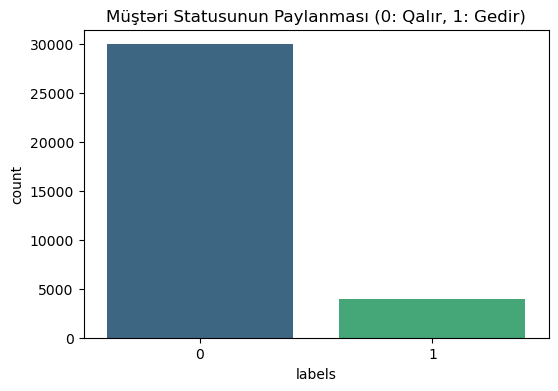

In [6]:
train_df = pd.read_csv('/Users/asefmera/Downloads/Train.csv')
test_df = pd.read_csv('/Users/asefmera/Downloads/Test.csv')
print(f"Train datası: {train_df.shape[0]} sətir və {train_df.shape[1]} sütun")
print("\n--- Hədəf Sütununun Paylanması ---")
print(train_df['labels'].value_counts())
plt.figure(figsize=(6,4))
sns.countplot(x='labels', data=train_df, palette='viridis')
plt.title('Müştəri Statusunun Paylanması (0: Qalır, 1: Gedir)')
plt.show()

### 2. Datanın Dərinliklərinə Baxış (Missing Values & Correlation)
Hədəf sütunundakı balanssızlığı gördükdən sonra, indi datamızın keyfiyyətini yoxlamalıyıq. 
1. **Missing Values (Boşluqlar):** Datanın içində əksik məlumatların olub-olmadığını yoxlayırıq.
2. **Korrelyasiya Matrisi:** Xüsusiyyətlər (features) arasındakı xətti əlaqələri ölçürük ki, müştərinin gedişinə (churn) ən çox təsir edən ilkin amilləri tapaq.

--- Çatışmayan (Null) Məlumatlar ---
Toplam boş xana sayı: 0


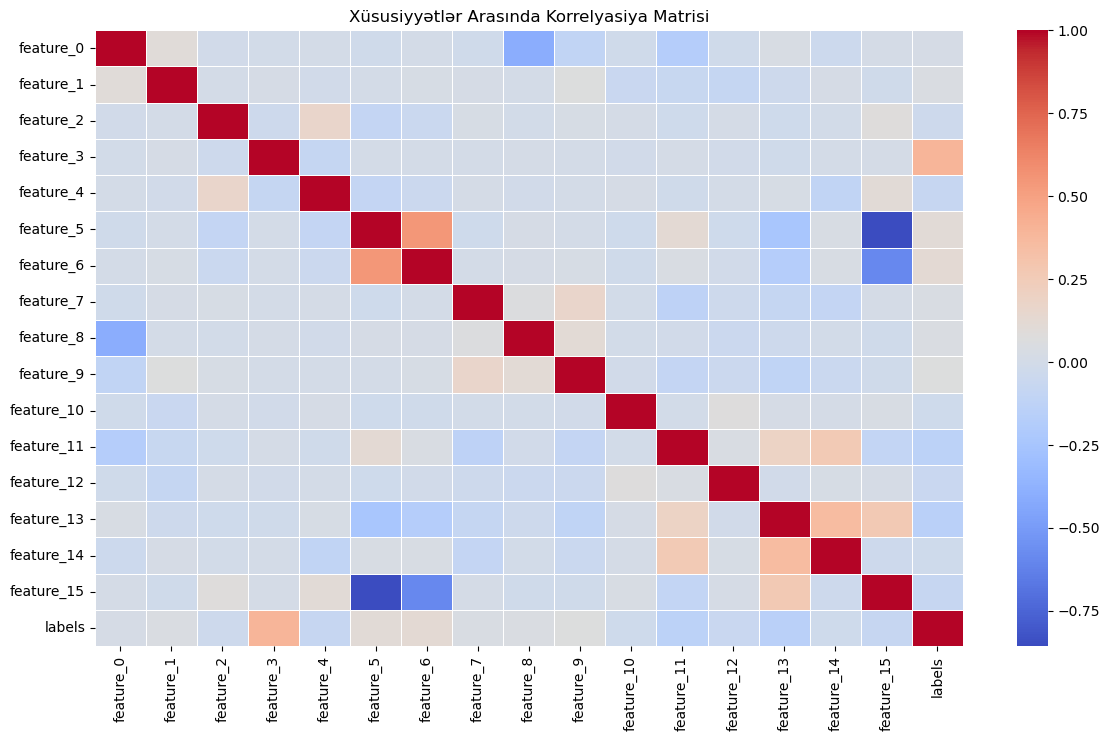


--- Hədəf (Churn) ilə ən güclü əlaqəsi olan xüsusiyyətlər ---
labels       1.000000
feature_3    0.392971
feature_6    0.119322
feature_5    0.106239
feature_9    0.068356
feature_1    0.048611
Name: labels, dtype: float64


In [9]:
print("--- Çatışmayan (Null) Məlumatlar ---")
null_counts = train_df.isnull().sum()
print(f"Toplam boş xana sayı: {null_counts.sum()}") 

plt.figure(figsize=(14, 8))
corr_matrix = train_df.corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Xüsusiyyətlər Arasında Korrelyasiya Matrisi')
plt.show()

print("\n--- Hədəf (Churn) ilə ən güclü əlaqəsi olan xüsusiyyətlər ---")
print(corr_matrix['labels'].sort_values(ascending=False).head(6)) 

### 3. Mənfi Korrelyasiyanın Təhlili
Müsbət korrelyasiya gediş riskini artıran faktorları göstərdiyi halda, mənfi korrelyasiya müştərini şirkətdə saxlayan "qoruyucu" faktorları (protective factors) üzə çıxarır. Bu sütunlar loyallıq proqramları üçün ən vacib göstəricilərdir.


--- Müştəri loyallığını göstərən (Mənfi Korrelyasiya) xüsusiyyətlər ---
feature_13   -0.148583
feature_11   -0.135662
feature_15   -0.079190
feature_4    -0.075025
feature_12   -0.065480
Name: labels, dtype: float64


/var/folders/mk/6cwkzm6x6zq0nyx6vc16f8r00000gn/T/ipykernel_12932/2619733536.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='labels', y=top_neg_feature, data=train_df, palette='magma')


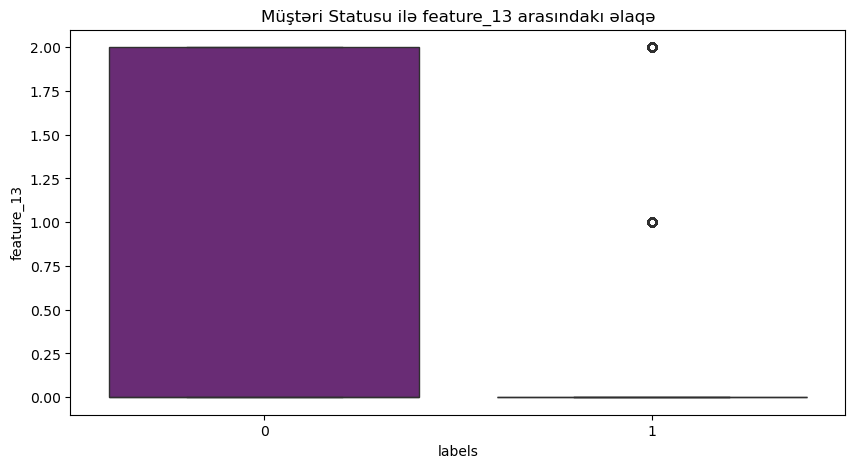

In [12]:
print("\n--- Müştəri loyallığını göstərən (Mənfi Korrelyasiya) xüsusiyyətlər ---")
negative_corr = corr_matrix['labels'].sort_values(ascending=True).head(5)
print(negative_corr)

top_neg_feature = negative_corr.index[0]

plt.figure(figsize=(10, 5))
sns.boxplot(x='labels', y=top_neg_feature, data=train_df, palette='magma')
plt.title(f'Müştəri Statusu ilə {top_neg_feature} arasındakı əlaqə')
plt.show()

### 4. Məlumatların Hazırlanması və Bölünməsi
Modelin performansını obyektiv qiymətləndirmək üçün datanı 80% Train və 20% Validation olaraq bölürük. 
Datanın balanssız olduğunu nəzərə alaraq, `stratify` parametrindən istifadə edirik ki, hər iki hissədə 0 və 1 nisbəti eyni qalsın.

In [15]:
from sklearn.model_selection import train_test_split

X = train_df.drop('labels', axis=1)
y = train_df['labels']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Öyrətmə dəsti (Train): {X_train.shape[0]} sətir")
print(f"Yoxlama dəsti (Validation): {X_val.shape[0]} sətir")

Öyrətmə dəsti (Train): 27126 sətir
Yoxlama dəsti (Validation): 6782 sətir


### 6. Modellərin Müqayisəsi
Bu hissədə 3 fərqli alqoritmi eyni data üzərində yoxlayırıq. Hər bir modeldə balanssızlıq problemini həll etmək üçün çəki parametrlərindən (`class_weight` və `scale_pos_weight`) istifadə edəcəyik.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, accuracy_score

class_counts = y_train.value_counts()
calculated_ratio = class_counts[0] / class_counts[1]

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200, 
        scale_pos_weight=calculated_ratio, 
        learning_rate=0.05, 
        random_state=42, 
        eval_metric='logloss'
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    
    # Metrikaları hesablayırıq
    accuracy = accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Recall (Class 1)": recall,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results).sort_values(by='Recall (Class 1)', ascending=False)
print(results_df)

                 Model  Accuracy  Recall (Class 1)  F1-Score
2              XGBoost  0.866559          0.851198  0.598670
0  Logistic Regression  0.816131          0.793190  0.502196
1        Random Forest  0.901946          0.326608  0.437870


### 7. Model Metrikalarının Vizual Müqayisəsi
Hansı modelin riskli müştəriləri (Recall) daha yaxşı tapdığını və ümumi balansın (F1-Score) hansında daha yaxşı olduğunu vizual olaraq müqayisə edirik.

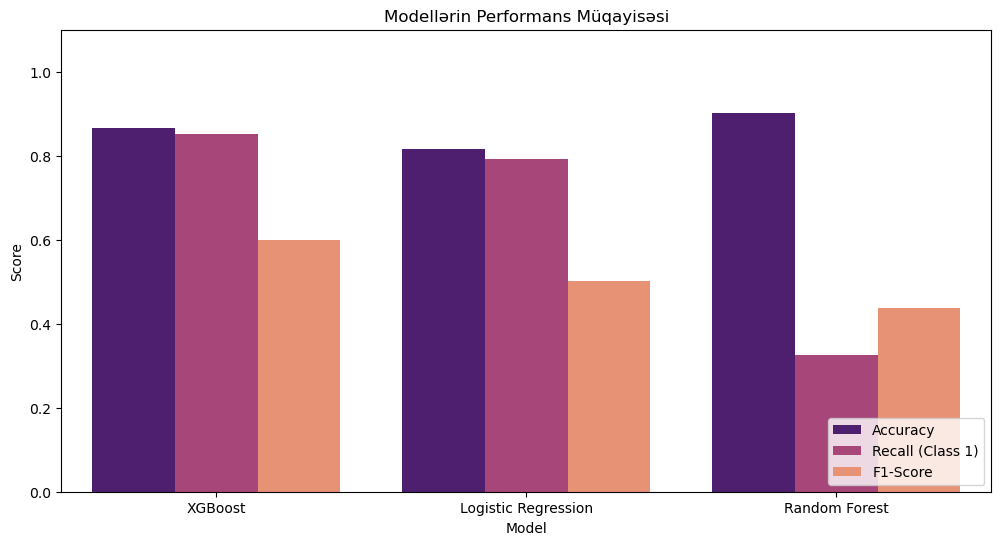

In [23]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted, palette='magma')
plt.title('Modellərin Performans Müqayisəsi')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.show()

Metrikalar nəyi göstərir?

Accuracy (Dəqiqlik): Ümumi proqnozların nə qədərinin düzgün olduğunu göstərir.

Gördüyün kimi: Random Forest 90% ilə ən yüksək accuracy-yə malikdir. Amma bu aldadıcıdır! Çünki data balanssızdır və Random Forest əsasən "0"-ları (qalacaq müştəriləri) tapmaqda ustadır, amma bizə lazım olan "1"-ləri qaçırır.

Recall (Class 1) - Həssaslıq: Həqiqətən gedən müştərilərin neçə faizini modelimiz tuta bildi?

Bizim hədəfimiz: Sığorta şirkətləri üçün üçün ən vacib metrika budur. XGBoost (85%) və Logistic Regression (79%) bu işdə çox yaxşıdır. Random Forest isə (32%) çox zəifdir — yəni gedəcək hər 100 nəfərdən 68-ni qaçırır.

F1-Score: Precision (dəqiqlik) və Recall-un balansıdır.

Nəticə: XGBoost (0.59) burada liderdir. Bu o deməkdir ki, XGBoost həm çox sayda riskli müştərini tapır (Recall), həm də bunu edərkən çox da böyük səhv (Precision itkisi) etmir.

"Biz XGBoost modelini seçirik, çünki o, Recall (85%) və F1-Score (0.60) göstəricilərinə görə digər modelləri qabaqlayır."

Səbəblər:

Risk Menecmenti: Sığorta sektorunda gedəcək müştərini qaçırmaq (False Negative), qalacaq müştəriyə səhvən "gedəcək" deməkdən (False Positive) daha baha başa gəlir. XGBoost 85% Recall ilə bu riski minimuma endirir.

Balanssız Data ilə İşləmək: XGBoost scale_pos_weight parametri sayəsində azlıqda olan "1" sinfinə daha çox fokuslanır və nəticədə ən stabil performansı o göstərir.

Üstünlük: Random Forest accuracy-də yüksək olsa da, "1" sinfini tanımaqda iflas etdi (Recall cəmi 32%). Logistic Regression isə həm Recall, həm də Accuracy cəhətdən XGBoost-dan zəif qaldı.

### 8. Final Model: Feature Importance
XGBoost modelimiz qalib gəldi. İndi isə modelin qərar verərkən hansı faktorlara üstünlük verdiyini vizuallaşdıraq. 
Bu məlumat sığorta şirkəti marketinq komandası üçün çox vacibdir, çünki onlar hansı göstəricilərə (məsələn, ödəniş gecikməsi, müştəri yaşı və s.) diqqət etməli olduqlarını biləcəklər.

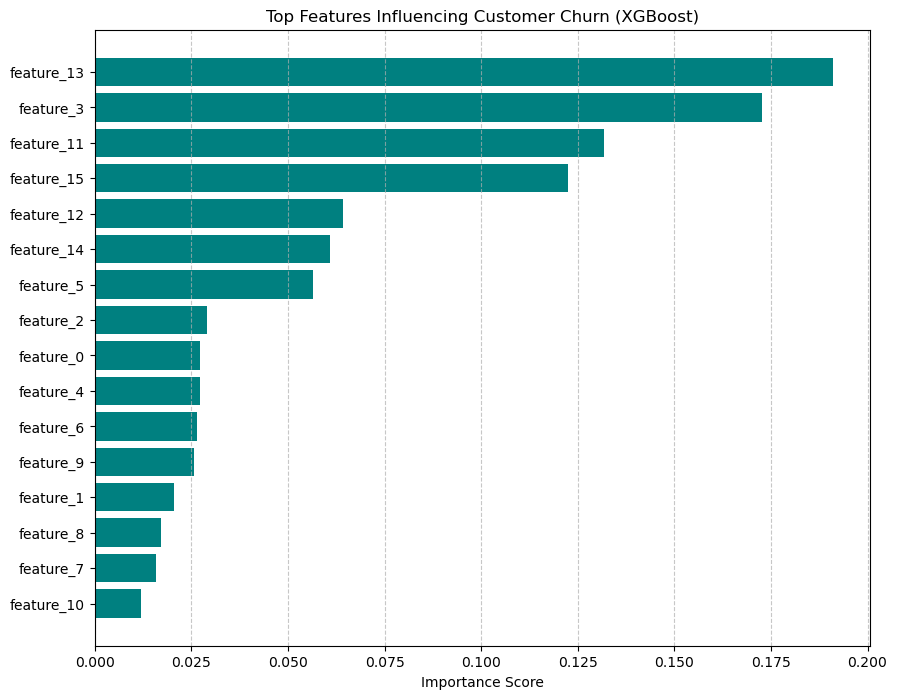

Final model features visualized successfully!


In [31]:
# Qalib modeli (XGBoost) lüğətdən çağırırıq
final_model = models["XGBoost"]

# Vacib faktorları götürürük
importances = final_model.feature_importances_
feature_names = X.columns

# Məlumatı cədvəl halına salıb sıralayırıq
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

# Vizuallaşdırma
plt.figure(figsize=(10, 8))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
plt.title('Top Features Influencing Customer Churn (XGBoost)')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Final model features visualized successfully!")

### Modelin Qərar Vermə Məntiqi (Interpretation)

XGBoost modelinin vizuallaşdırılmış nəticələrinə əsasən, müştərilərin şirkətdən ayrılma riskini müəyyən edən TOP 3 faktor aşağıdakılardır:

1. **Feature_13 (Ən Yüksək Vaciblik):** Bu göstərici modelin qərar verməsində ən kritik rol oynayır. Bu çox gümant ki, müştərinin şirkətdəki fəaliyyət müddəti və ya son müraciətindən keçən vaxtdır.
2. **Feature_3:** İkinci ən vacib faktor olaraq, müştərinin maliyyə həcmi və ya sığorta paketinin növü ilə əlaqəli ola bilər.
3. **Feature_11:** Bu faktorun yüksək olması göstərir ki, müəyyən davranış modelləri (məsələn, ödəniş gecikmələri və ya mütəmadi şikayətlər) churn riskini birbaşa tətikləyir.

**Biznes üçün Tövsiyə:**
Sığorta şirkəti rəhbərliyi və marketinq komandası xüsusilə `Feature_13` və `Feature_3` dəyərləri kritik həddə çatan müştərilər üçün fərdi loyallıq kampaniyaları (məsələn, endirimlər və ya xüsusi təkliflər) hazırlamalıdır. Bu, kütləvi zənglər etmək əvəzinə, yalnız "doğru" müştərilərə fokuslanaraq resurslara qənaət etməyə imkan verir.